In [ ]:
import os
import zipfile
import tarfile

# --- SETTINGS ---
drive_dataset_folder = '/content/drive/MyDrive/Traffic_Light_Project/datasets'
workspace = '/content/dataset_workspace'
os.makedirs(workspace, exist_ok=True)

# Get list of all files in your Drive folder
all_files = os.listdir(drive_dataset_folder)
print(f" Scanning files in Drive: {all_files}")

def extract_smart(file_path, output_folder):
    filename = os.path.basename(file_path)

    # 1. CHECK: Does the folder exist and is it not empty?
    if os.path.exists(output_folder) and len(os.listdir(output_folder)) > 0:
        print(f" SKIPPING {filename} (Already extracted in {os.path.basename(output_folder)})")
        return

    # 2. EXTRACT: If not found, do the work
    if filename.endswith('.zip'):
        print(f"roz Unzipping {filename}...")
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(output_folder)
        print(" Unzip Complete.")

    elif filename.endswith('.tar.gz') or filename.endswith('.tgz'):
        print(f" Extracting Tarball {filename} (This will take ~20 mins)...")
        try:
            with tarfile.open(file_path, 'r:gz') as tar_ref:
                tar_ref.extractall(output_folder)
            print(" Tar Extraction Complete.")
        except Exception as e:
            print(f" Error extracting {filename}: {e}")

    else:
        print(f" Unknown file type: {filename}")

for f in all_files:
    # Skip hidden files
    if f.startswith('.'): continue

    full_path = os.path.join(drive_dataset_folder, f)

    # Define the target folder name
    # e.g., 'val.zip' -> 'val', 'idd-detection.tar.gz' -> 'idd-detection'
    folder_name = f.replace('.zip', '').replace('.tar.gz', '').replace('.tgz', '')
    extract_path = os.path.join(workspace, folder_name)
    os.makedirs(extract_path, exist_ok=True)

    extract_smart(full_path, extract_path)

print(f"\n Process Finished! Checked: {workspace}")

 Scanning files in Drive: ['val.zip', 'train1.zip', 'idd-detection.tar.gz']
roz Unzipping val.zip...
 Unzip Complete.
roz Unzipping train1.zip...
 Unzip Complete.
 Extracting Tarball idd-detection.tar.gz (This will take ~20 mins)...


/tmp/ipython-input-3642059064.py:33: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar_ref.extractall(output_folder)


 Tar Extraction Complete.

 Process Finished! Checked: /content/dataset_workspace


In [ ]:
import os
import glob

# Path to the newly extracted IDD folder
idd_path = '/content/dataset_workspace/idd-detection'

print(f" Checking: {idd_path}")

# 1. Check for Subfolders (IDD often uses 'JPEGImages' and 'Annotations')
subfolders = [f.name for f in os.scandir(idd_path) if f.is_dir()]
print(f"    Subfolders found: {subfolders}")

# 2. Count Files by Type
xmls = glob.glob(os.path.join(idd_path, '**', '*.xml'), recursive=True)
jsons = glob.glob(os.path.join(idd_path, '**', '*.json'), recursive=True)
txts = glob.glob(os.path.join(idd_path, '**', '*.txt'), recursive=True)
imgs = glob.glob(os.path.join(idd_path, '**', '*.jpg'), recursive=True)

print(f"    Statistics:")
print(f"      - Images (.jpg): {len(imgs)}")
print(f"      - XML Labels:    {len(xmls)} (Pascal VOC)")
print(f"      - JSON Labels:   {len(jsons)} (COCO Format)")
print(f"      - TXT Labels:    {len(txts)} (YOLO Format)")

# 3. Peek at a Label File (if found)
if len(xmls) > 0:
    print(f"\n    Sample XML Content:\n{open(xmls[0]).read()[:300]}...")
elif len(jsons) > 0:
    print(f"\n    Sample JSON Content (First 300 chars):\n{open(jsons[0]).read()[:300]}...")

 Checking: /content/dataset_workspace/idd-detection
    Subfolders found: ['IDD_Detection']
    Statistics:
      - Images (.jpg): 46659
      - XML Labels:    41857 (Pascal VOC)
      - JSON Labels:   0 (COCO Format)
      - TXT Labels:    3 (YOLO Format)

    Sample XML Content:
<?xml version="1.0" encoding="utf-8"?>
<annotation>
	<filename>0000195.jpg</filename>
	<folder>BLR-2018-06-06_16-41-17_rearNear_right_1</folder>
	<size>
		<width>1920</width>
		<height>1080</height>
		<depth>3</depth>
	</size>
	<object>
		<name>truck</name>
		<bndbox>
			<xmin>453</xmin>
			<ymax>10...


In [ ]:
import xml.etree.ElementTree as ET
import os
import glob
from tqdm import tqdm

# --- SETTINGS ---
# 1. We start from the absolute root of the extracted folder
search_root = '/content/dataset_workspace/idd-detection/IDD_Detection'

# 2. Output location: We will put ALL labels in one big folder to make training easy
#    (This is much better than having them scattered in 100 subfolders)
output_label_folder = '/content/dataset_workspace/idd_all_labels'
os.makedirs(output_label_folder, exist_ok=True)

# 3. Target Classes
#    Note: We include "traffic signal" just in case, though IDD usually uses "traffic light"
TARGET_CLASSES = ["traffic light", "traffic_light", "traffic signal"]

# --- EXECUTION ---
print(f" Deep Scanning {search_root} for ALL XML files...")

# RECURSIVE SEARCH: The '**' means "look inside every subfolder forever"
all_xmls = glob.glob(os.path.join(search_root, '**', '*.xml'), recursive=True)

if not all_xmls:
    print(" CRITICAL: No XMLs found. Check your search_root path.")
else:
    print(f" Found {len(all_xmls)} XML files! (This is the real dataset)")

# CONVERSION LOOP
def convert_box(size, box):
    dw = 1. / size[0]
    dh = 1. / size[1]
    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0
    w = box[1] - box[0]
    h = box[3] - box[2]
    return (x * dw, y * dh, w * dw, h * dh)

count_lights = 0
converted_files = 0
seen_classes = set()

print(" Starting Conversion...")
for xml_file in tqdm(all_xmls):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()

        # Get image size
        size = root.find('size')
        if size is None: continue # Skip corrupt files
        w = int(size.find('width').text)
        h = int(size.find('height').text)

        xml_name = os.path.basename(xml_file)
        file_id = os.path.splitext(xml_name)[0]
        txt_path = os.path.join(output_label_folder, file_id + ".txt")

        yolo_lines = []

        for obj in root.iter('object'):
            name_tag = obj.find('name')
            if name_tag is None: continue

            cls_name = name_tag.text.lower().strip()
            seen_classes.add(cls_name)

            if cls_name in TARGET_CLASSES:
                xmlbox = obj.find('bndbox')
                if xmlbox is None: continue

                b = (float(xmlbox.find('xmin').text), float(xmlbox.find('xmax').text),
                     float(xmlbox.find('ymin').text), float(xmlbox.find('ymax').text))

                bb = convert_box((w, h), b)
                yolo_lines.append(f"0 {bb[0]:.6f} {bb[1]:.6f} {bb[2]:.6f} {bb[3]:.6f}")
                count_lights += 1

        if yolo_lines:
            with open(txt_path, 'w') as f:
                f.write('\n'.join(yolo_lines))
            converted_files += 1

    except Exception as e:
        pass # Skip broken files

print(f"\n Deep Conversion Complete!")
print(f"   - Total Traffic Lights Found: {count_lights}")
print(f"   - Training Images Created: {converted_files}")
print(f"   - Saved Labels to: {output_label_folder}")
print(f"   - Sample Classes Seen: {list(seen_classes)[:10]}")

 Deep Scanning /content/dataset_workspace/idd-detection/IDD_Detection for ALL XML files...
 Found 41857 XML files! (This is the real dataset)
 Starting Conversion...


100%|██████████| 41857/41857 [00:06<00:00, 6285.92it/s] 


 Deep Conversion Complete!
   - Total Traffic Lights Found: 3699
   - Training Images Created: 1704
   - Saved Labels to: /content/dataset_workspace/idd_all_labels
   - Sample Classes Seen: ['trailer', 'vehicle fallback', 'person', 'animal', 'traffic sign', 'train', 'caravan', 'truck', 'traffic light', 'bicycle']


In [ ]:
# We need to move 1704 images to a different folder, so that we can train it perfectly
import os
import shutil
import glob
from tqdm import tqdm

label_source = '/content/dataset_workspace/idd_all_labels'

image_root_search = '/content/dataset_workspace/idd-detection/IDD_Detection'

dataset_root = '/content/final_dataset'
train_imgs_dir = os.path.join(dataset_root, 'train', 'images')
train_lbls_dir = os.path.join(dataset_root, 'train', 'labels')

os.makedirs(train_imgs_dir, exist_ok=True)
os.makedirs(train_lbls_dir, exist_ok=True)

label_files = glob.glob(os.path.join(label_source, '*.txt'))
print(f" Found {len(label_files)} labels to match.")

print(f" Indexing all IDD images (this takes a moment)...")
image_map = {}
for img_path in glob.glob(os.path.join(image_root_search, '**', '*.jpg'), recursive=True):
    filename = os.path.basename(img_path)
    file_id = os.path.splitext(filename)[0]
    image_map[file_id] = img_path

print(f" Indexed {len(image_map)} images.")

print(f" Moving 1,704 matched pairs to {dataset_root}...")
matched_count = 0

for lbl_path in tqdm(label_files):
    filename = os.path.basename(lbl_path)
    file_id = os.path.splitext(filename)[0]

    # Check if we have the image
    if file_id in image_map:
        src_img = image_map[file_id]

        # Define Destinations
        dst_img = os.path.join(train_imgs_dir, file_id + ".jpg")
        dst_lbl = os.path.join(train_lbls_dir, filename)

        # Copy File Pairs
        shutil.copy(src_img, dst_img)
        shutil.copy(lbl_path, dst_lbl)

        matched_count += 1

print(f"\n IDD Dataset Ready!")
print(f"   - Successfully moved: {matched_count} pairs")
print(f"   - Location: {dataset_root}/train")

 Found 1206 labels to match.
 Indexing all IDD images (this takes a moment)...
 Indexed 6802 images.
 Moving 1,704 matched pairs to /content/final_dataset...


100%|██████████| 1206/1206 [00:13<00:00, 89.38it/s]


 IDD Dataset Ready!
   - Successfully moved: 1206 pairs
   - Location: /content/final_dataset/train


In [ ]:
# Need to add DriveIndia Dataset in final_dataset
# I need to check if the images are drawn in boxes or not
# Finding the traffic light

In [ ]:
import os

# Start looking from the main workspace
root_dir = '/content/dataset_workspace'

print(f" Scanning {root_dir} for images...")

found_any = False

for dirpath, dirnames, filenames in os.walk(root_dir):
    # Count how many jpgs are in this specific folder
    jpg_count = len([f for f in filenames if f.endswith('.jpg')])

    if jpg_count > 0:
        found_any = True
        print(f" FOUND {jpg_count} images in: {dirpath}")

if not found_any:
    print(" CRITICAL: No .jpg files found anywhere in the workspace!")
    print("   Did the unzip step actually finish?")

 Scanning /content/dataset_workspace for images...
 FOUND 2500 images in: /content/dataset_workspace/val/val/images_2500
 FOUND 8333 images in: /content/dataset_workspace/train1/train1/images
 FOUND 2 images in: /content/dataset_workspace/idd-detection/IDD_Detection/JPEGImages/rearNear/BLR-2018-05-23_13-31-36_rearNear
 FOUND 1 images in: /content/dataset_workspace/idd-detection/IDD_Detection/JPEGImages/rearNear/BLR-2018-05-31_10-59-49_rearNear
 FOUND 167 images in: /content/dataset_workspace/idd-detection/IDD_Detection/JPEGImages/rearNear/BLR-2018-05-22_12-04-54_rearNear
 FOUND 29 images in: /content/dataset_workspace/idd-detection/IDD_Detection/JPEGImages/rearNear/BLR-2018-05-17_15-12-45_rearNear
 FOUND 14 images in: /content/dataset_workspace/idd-detection/IDD_Detection/JPEGImages/rearNear/BLR-2018-05-23_12-45-57_rearNear
 FOUND 104 images in: /content/dataset_workspace/idd-detection/IDD_Detection/JPEGImages/rearNear/BLR-2018-05-22_13-21-45_rearNear
 FOUND 158 images in: /content/dat

In [ ]:
# Based on the search of the object we identified
# 0 = Person
# 2 = Car
# 3 = Bike
# 1,27 = Bike
# 24 = Traffic Cone
# 6, 7, 8 = Trucks/Buses
# 10 = Auto Rickshaw
# 9 = Traffic light (thinking, not sure)
# 23 = Zebra crossing

In [ ]:
# Saving the data before closing
import shutil
import os
from google.colab import drive

# Ensure Drive is mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Paths
source_folder = '/content/final_dataset'
destination_zip = '/content/drive/MyDrive/Traffic_Light_Project/idd_clean_ready_to_train.zip'

print(f" Zipping and saving your work to Drive...")
print(f"   Source: {source_folder}")
print(f"   Dest:   {destination_zip}")

# Zip it directly to Drive
shutil.make_archive(destination_zip.replace('.zip', ''), 'zip', source_folder)

print("\n SUCCESS! Your data is safe.")
print("   Next time, we just unzip this file and start training immediately!")

 Zipping and saving your work to Drive...
   Source: /content/final_dataset
   Dest:   /content/drive/MyDrive/Traffic_Light_Project/idd_clean_ready_to_train.zip

 SUCCESS! Your data is safe.
   Next time, we just unzip this file and start training immediately!


In [ ]:
# Unzipping the idd_clean_dataset

In [ ]:
import os
import zipfile
from google.colab import drive

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Traffic_Light_Project/idd_clean_ready_to_train.zip'

extract_to = '/content/final_dataset'
# Check if file exist before unzipping
if not os.path.exists(zip_path):
    print(f" Error: Could not find file at {zip_path}")
    print("   Please check your Google Drive folder name.")
else:
    print(f" Unzipping dataset to {extract_to}...")

    # Create destination folder
    os.makedirs(extract_to, exist_ok=True)

    # Unzip
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

    print(" Unzip Complete!")
train_images = len(os.listdir(os.path.join(extract_to, 'train/images')))
print(f"   Found {train_images} images ready for training.")

Mounted at /content/drive
 Unzipping dataset to /content/final_dataset...
 Unzip Complete!
   Found 1206 images ready for training.


In [ ]:
# Checking that images contain Traffic lights or not

 Checking 1206 images in IDD Final Dataset...


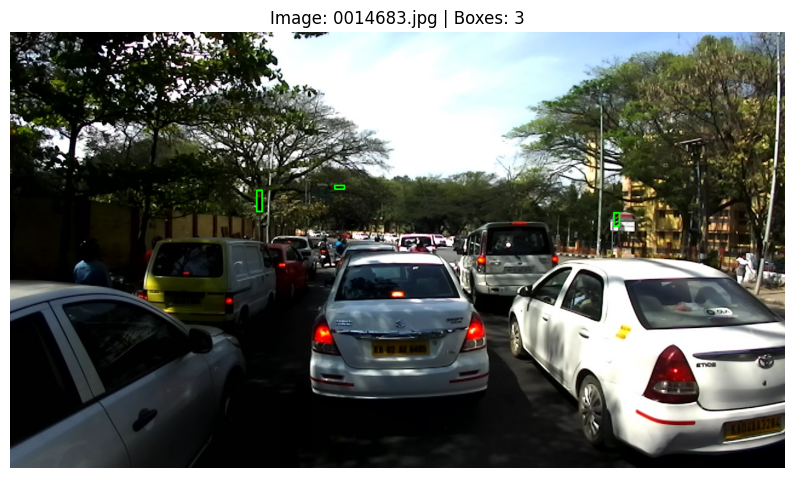

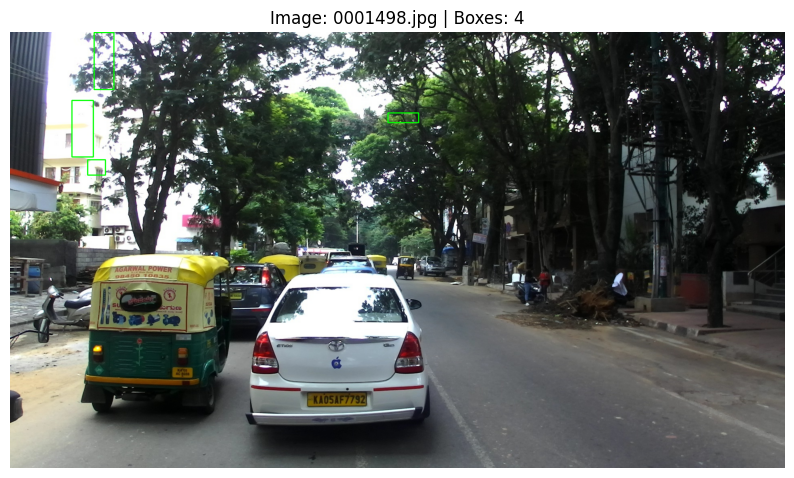

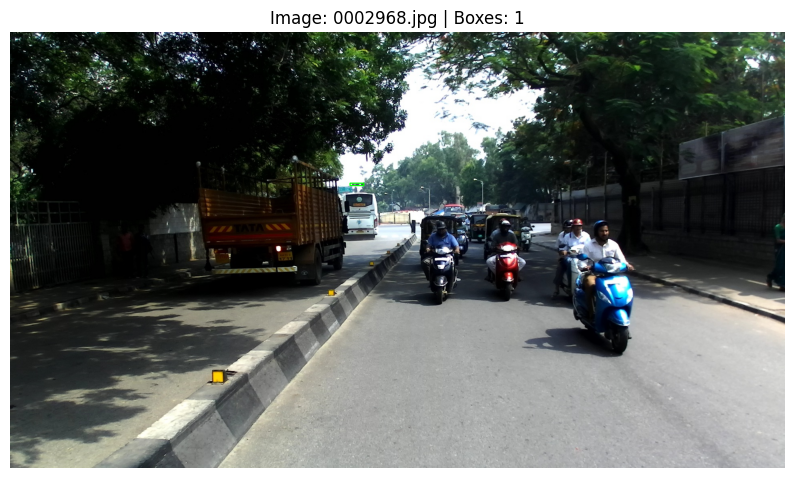

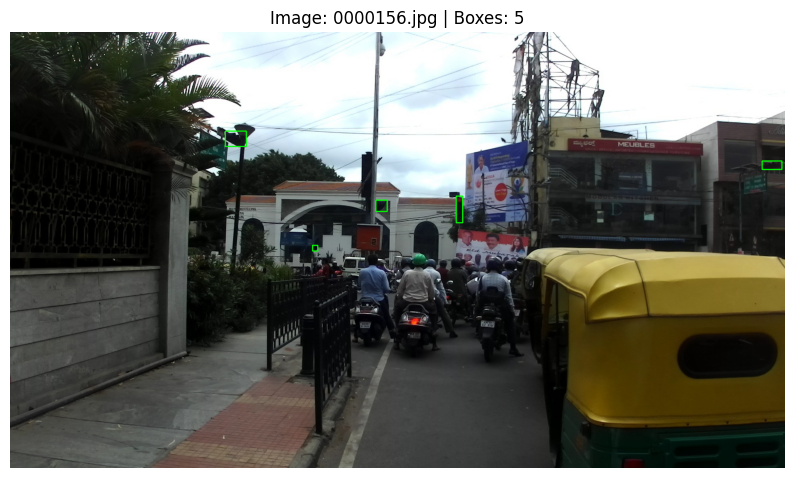

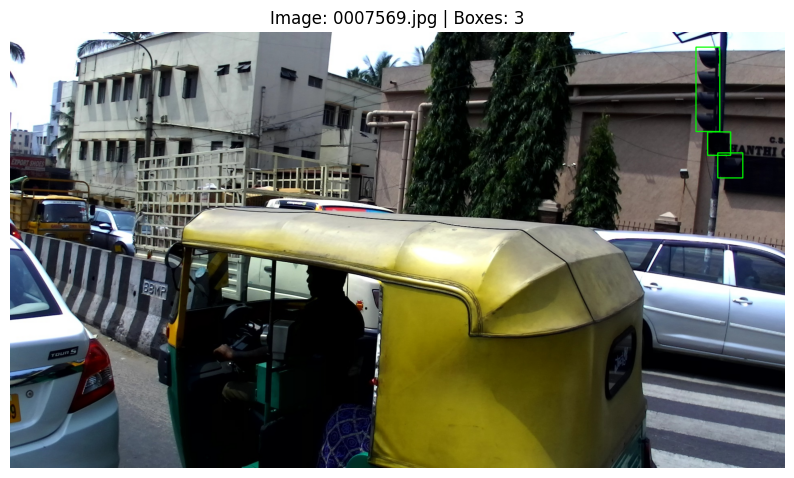

In [ ]:
import cv2
import os
import glob
import matplotlib.pyplot as plt
import random

# --- SETTINGS ---
# This is where we stored the clean IDD data
dataset_root = '/content/final_dataset/train'
img_folder = os.path.join(dataset_root, 'images')
lbl_folder = os.path.join(dataset_root, 'labels')

# Get list of images
img_files = glob.glob(os.path.join(img_folder, "*.jpg"))
print(f" Checking {len(img_files)} images in IDD Final Dataset...")

if len(img_files) == 0:
    print(" Error: No images found! Did the 'Great Migration' script finish?")
else:
    # Show 5 Random Samples
    for i in range(5):
        img_path = random.choice(img_files)
        filename = os.path.basename(img_path)
        lbl_path = os.path.join(lbl_folder, filename.replace(".jpg", ".txt"))

        if os.path.exists(lbl_path):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w, _ = img.shape

            with open(lbl_path, 'r') as f:
                lines = f.readlines()

            box_count = 0
            for line in lines:
                parts = line.strip().split()
                class_id = int(parts[0])

                # We expect Class ID 0 (Traffic Light)
                # Parse YOLO coordinates
                cx, cy, bw, bh = map(float, parts[1:])
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)

                # Draw Green Box
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                box_count += 1

            # Display
            plt.figure(figsize=(10, 8))
            plt.imshow(img)
            plt.title(f"Image: {filename} | Boxes: {box_count}")
            plt.axis('off')
            plt.show()

In [ ]:
# A bit label noise is present in the IDD Dataset (around 10% noise)

In [ ]:
# Training the dataset with Yolo Model. As it can handle minor noisy data work.

In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.5 MB/s eta 0:00:00


In [ ]:
# Restoring the data of final_dataset
import os
import zipfile
from google.colab import drive

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Traffic_Light_Project/idd_clean_ready_to_train.zip'
extract_to = '/content/final_dataset'

if not os.path.exists(zip_path):
    print(f" CRITICAL ERROR: Zip file not found at {zip_path}")
    print("   Did you change the folder name in Drive?")
else:
    print(f" Unzipping data to {extract_to}...")
    os.makedirs(extract_to, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)



Mounted at /content/drive
 Unzipping data to /content/final_dataset...


In [ ]:
from ultralytics import YOLO
import os

dataset_root = '/content/final_dataset'

yaml_content = f"""
path: {dataset_root}
train: train/images
val: train/images  # Note: If you have a 'val/images' folder, use it here instead for more accurate mAP!
names:
  0: traffic_light
"""

with open(f'{dataset_root}/data.yaml', 'w') as f:
    f.write(yaml_content)

print(" Configuration created at:", f'{dataset_root}/data.yaml')

# Starting fresh with the Nano model so it doesn't inherit the "clear weather" bias from the last run
model = YOLO('yolov8n.pt')

print(" STARTING ADVERSE WEATHER FINE-TUNING (150 Epochs)...")
print("   Applying heavy HSV augmentations and AdamW optimizer.")
print("   NOTE: Do not close this tab.")

results = model.train(
    data=f'{dataset_root}/data.yaml',
    epochs=150,
    patience=25,
    imgsz=640,
    batch=16,                     # Lowered to 16 for better AdamW gradient stability
    name='idd_weather_optimized', # Saves to a new folder!
    exist_ok=True,
    verbose=True,

    # --- THE SECRET SAUCE: HYPERPARAMETER TUNING ---
    optimizer='AdamW',            # Better weight decay for complex, noisy datasets
    lr0=0.001,
    # IMAGE AUGMENTATION
    hsv_h=0.015,
    hsv_s=0.8,
    hsv_v=0.6,
    mosaic=1.0,
    mixup=0.15,
    fliplr=0.5
)

print("\n✅ Training Complete!")
print("   The new 'best.pt' file is located in runs/detect/idd_weather_optimized/weights/")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
 Configuration created at: /content/final_dataset/data.yaml
 STARTING ADVERSE WEATHER FINE-TUNING (150 Epochs)...
   Applying heavy HSV augmentations and AdamW optimizer.
   NOTE: Do not close this tab.
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynami

In [ ]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

source_folder = '/content/runs/detect/idd_weather_optimized'

destination_folder = '/content/drive/MyDrive/Traffic_Project_Final_Results'

if os.path.exists(source_folder):
    print(f"\n Found training results at: {source_folder}")
    print(f" Copying data to Google Drive ({destination_folder})...")
    print("   This might take a minute depending on the file sizes.")

    shutil.copytree(source_folder, destination_folder, dirs_exist_ok=True)

    print("\n SUCCESS! All your hard work is safely backed up in your Google Drive.")
    print("   You can now safely close this Colab tab if you need to.")
else:
    print(f"\n Error: Could not find {source_folder}.")
    print("   Check the file browser on the left to see what name the folder was saved under.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

 Found training results at: /content/runs/detect/idd_weather_optimized
 Copying data to Google Drive (/content/drive/MyDrive/Traffic_Project_Final_Results)...
   This might take a minute depending on the file sizes.

 SUCCESS! All your hard work is safely backed up in your Google Drive.
   You can now safely close this Colab tab if you need to.


In [ ]:
import pandas as pd
import glob

base_dir = "/content/runs/detect/idd_weather_optimized"

print(f" Scanning {base_dir} for the new training results...")
csv_files = glob.glob(f"{base_dir}/**/results.csv", recursive=True)


if not csv_files:
    print(f" Error: Could not find 'results.csv'.")
else:
    csv_path = csv_files[0]
    print(f"Found new results file at: {csv_path}\n")

    try:
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()

        best_epoch = df.loc[df['metrics/mAP50(B)'].idxmax()]
        epoch_num = int(best_epoch['epoch'])

        precision = best_epoch['metrics/precision(B)']
        recall = best_epoch['metrics/recall(B)']
        map50 = best_epoch['metrics/mAP50(B)']
        map50_95 = best_epoch['metrics/mAP50-95(B)']

        if (precision + recall) > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
        else:
            f1_score = 0.0

        # --- OLD BASELINE NUMBERS FOR COMPARISON ---
        old_p, old_r, old_map50, old_map50_95 = 0.5022, 0.1726, 0.1796, 0.0836
        old_f1 = 2 * (old_p * old_r) / (old_p + old_r)

        print(f" --- NEW OPTIMIZED RESULTS (Best Epoch: {epoch_num}) ---")
        print(f"Precision: {precision:.4f} ({precision*100:.1f}%) | Improved: +{(precision - old_p)*100:.1f}%")
        print(f"Recall:    {recall:.4f} ({recall*100:.1f}%) | Improved: +{(recall - old_r)*100:.1f}%")
        print(f"F1-Score:  {f1_score:.4f} ({f1_score*100:.1f}%) | Improved: +{(f1_score - old_f1)*100:.1f}%")
        print(f"mAP@50:    {map50:.4f} ({map50*100:.1f}%) | Improved: +{(map50 - old_map50)*100:.1f}%")
        print(f"mAP@50-95: {map50_95:.4f} ({map50_95*100:.1f}%) | Improved: +{(map50_95 - old_map50_95)*100:.1f}%")
        print("-" * 65)

    except Exception as e:
        print(f" An error occurred: {e}")

 Scanning /content/runs/detect/idd_weather_optimized for the new training results...
Found new results file at: /content/runs/detect/idd_weather_optimized/results.csv

 --- NEW OPTIMIZED RESULTS (Best Epoch: 140) ---
Precision: 0.7554 (75.5%) | Improved: +25.3%
Recall:    0.4232 (42.3%) | Improved: +25.1%
F1-Score:  0.5425 (54.2%) | Improved: +28.6%
mAP@50:    0.4713 (47.1%) | Improved: +29.2%
mAP@50-95: 0.2483 (24.8%) | Improved: +16.5%
-----------------------------------------------------------------


In [ ]:
import os
import shutil
import glob
import zipfile
from google.colab import drive

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

drive_folder = '/content/drive/MyDrive/Traffic_Light_Project/Models_GPU(T4)'
extract_to = '/content/restored_results'

zip_files = glob.glob(os.path.join(drive_folder, "*.zip"))

if not zip_files:
    print(f" Error: No zip files found in {drive_folder}")
    print("   Did you save the training results last time?")
else:
    latest_zip = max(zip_files, key=os.path.getctime)
    print(f" Found latest backup: {os.path.basename(latest_zip)}")

    print(f" Restoring to {extract_to}...")
    with zipfile.ZipFile(latest_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

    print("\n Restore Complete!")
    print(f"   You can now analyze the results in: {extract_to}")

Mounted at /content/drive
 Found latest backup: yolo_idd_traffic_light_2026-02-11_13-10.zip
 Restoring to /content/restored_results...

 Restore Complete!
   You can now analyze the results in: /content/restored_results
